# 가평군 1330 버스 배차 불균형 분석 및 조정 시뮬레이션

초기 데이터에서 설계한 도착 Event 판정 방법을 최종 수집자료에 적용하여 2026년 9월 15일~29일 청평터미널 서울방향 1330-2·1330-4·1330-44의 Headway, 배차 불균형, 반복 패턴과 조정 가능성을 분석함.


## 1. 분석 데이터 불러오기

최종 수집자료를 불러온 뒤 분석기간을 9/15~9/29로 제한하고, 동일 차량의 반복 운행을 episode로 구분함.


In [20]:
# ============================================================
# 최종 분석 데이터 불러오기
# ============================================================

import urllib.request
from pathlib import Path
import pandas as pd
import numpy as np

FILE_ID = "1RnuZni1OH1er2ahTc92WhtbLlheAAHsl"
DOWNLOAD_URL = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"
input_file = Path("/content/1330_realtime_raw.xlsx")

print("원본 데이터 다운로드 중...")
urllib.request.urlretrieve(DOWNLOAD_URL, input_file)

# 로그인 페이지/권한 오류가 xlsx처럼 저장되는 경우를 방지
if input_file.stat().st_size < 10_000:
    raise RuntimeError(
        "다운로드된 파일이 너무 작습니다. Google 스프레드시트 공유 권한을 "
        "'링크가 있는 모든 사용자 - 뷰어'로 설정했는지 확인해주세요."
    )

with open(input_file, "rb") as f:
    header = f.read(200).lower()
if b"<html" in header or b"<!doctype html" in header:
    raise RuntimeError(
        "xlsx 대신 로그인/권한 페이지가 내려왔습니다. 공개 읽기 권한을 확인해주세요."
    )

print("다운로드 완료:", input_file)
print("파일 크기(KB):", round(input_file.stat().st_size / 1024, 1))

live = pd.read_excel(input_file)

required_cols = {
    "recorded_at", "station_name", "route_name",
    "vehicle_id", "predict_time_sec", "location_no"
}
missing = required_cols - set(live.columns)
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {sorted(missing)}")

live["recorded_at"] = pd.to_datetime(live["recorded_at"])

# 최종 분석기간을 9/15~9/29로 명시적으로 제한
# - 9/14: 테스트 및 초기 수집 오류 데이터 제외
# - 9/30 이후: 분석기간 밖 데이터이므로 자동 제외
live = live[
    (live["recorded_at"] >= pd.Timestamp("2026-09-15"))
    & (live["recorded_at"] < pd.Timestamp("2026-09-30"))
].copy()

live["date"] = live["recorded_at"].dt.date

for col in ["predict_time_sec", "location_no"]:
    live[col] = pd.to_numeric(live[col], errors="coerce")

# 이후 기존 코드와 동일하게 사용
df14 = live.copy()

# 날짜별 수집 종료시각
df14["collection_end"] = df14.groupby("date")["recorded_at"].transform("max")

# 동일 정류장·날짜·노선·차량에서 90분 이상 공백이면 새 episode
df14 = df14.sort_values(["station_name", "date", "route_name", "vehicle_id", "recorded_at"]).copy()
df14["gap_min"] = (
    df14.groupby(["station_name", "date", "route_name", "vehicle_id"])["recorded_at"]
        .diff().dt.total_seconds().div(60)
)
df14["new_episode"] = df14["gap_min"].isna() | (df14["gap_min"] >= 90)
df14["episode_no"] = (
    df14.groupby(["station_name", "date", "route_name", "vehicle_id"])["new_episode"]
        .cumsum().astype(int)
)
df14["episode_id"] = (
    df14["date"].astype(str) + "_" +
    df14["station_name"].astype(str) + "_" +
    df14["route_name"].astype(str) + "_" +
    df14["vehicle_id"].astype(str) + "_" +
    df14["episode_no"].astype(str)
)

print("분석기간:", live["recorded_at"].min(), "~", live["recorded_at"].max())
print("분석 행 수:", len(live))
print("분석 날짜 수:", live["date"].nunique())
print("정류장:", sorted(live["station_name"].dropna().unique()))


원본 데이터 다운로드 중...
다운로드 완료: /content/1330_realtime_raw.xlsx
파일 크기(KB): 1244.7
분석기간: 2026-09-15 06:00:49 ~ 2026-09-29 20:58:48
분석 행 수: 18034
분석 날짜 수: 11
정류장: ['마석역', '청평터미널']


## 2. 청평–마석 동일 운행 매칭

동일 날짜·노선·차량이며 청평→마석 관측 차이가 15~60분인 episode를 1:1로 연결함. 복수 후보가 있을 때 약 26분을 tie-break 기준으로 사용함.


In [21]:
# ============================================================
# 2. 청평 → 마석 동일 운행 episode 1:1 매칭
# ============================================================

episode = (
    df14.sort_values("recorded_at")
        .groupby(
            ["date", "station_name", "route_name", "vehicle_id", "episode_id"],
            as_index=False
        )
        .agg(
            first_seen=("recorded_at", "min"),
            last_seen=("recorded_at", "max"),
            n_obs=("recorded_at", "size"),
            first_eta=("predict_time_sec", "first"),
            last_eta=("predict_time_sec", "last"),
            first_location=("location_no", "first"),
            last_location=("location_no", "last"),
            collection_end=("collection_end", "first")
        )
)

cp17 = episode[episode["station_name"] == "청평터미널"].copy()
ms17 = episode[episode["station_name"] == "마석역"].copy()

cp17 = cp17.rename(columns={
    "episode_id": "cp_episode",
    "first_seen": "cp_first_seen",
    "last_seen": "cp_last_seen",
    "n_obs": "cp_n_obs",
    "first_eta": "cp_first_eta",
    "last_eta": "cp_last_eta",
    "first_location": "cp_first_location",
    "last_location": "cp_last_location",
    "collection_end": "cp_collection_end"
})

ms17 = ms17.rename(columns={
    "episode_id": "ms_episode",
    "first_seen": "ms_first_seen",
    "last_seen": "ms_last_seen",
    "n_obs": "ms_n_obs",
    "first_eta": "ms_first_eta",
    "last_eta": "ms_last_eta",
    "first_location": "ms_first_location",
    "last_location": "ms_last_location",
    "collection_end": "ms_collection_end"
})

pairs17 = cp17.merge(
    ms17,
    on=["date", "route_name", "vehicle_id"],
    how="inner"
)

pairs17["last_seen_travel_min"] = (
    pairs17["ms_last_seen"] - pairs17["cp_last_seen"]
).dt.total_seconds() / 60

# 잘못된 장시간 오매칭 방지를 위한 넓은 매칭 window
possible17 = pairs17[
    pairs17["last_seen_travel_min"].between(15, 60, inclusive="both")
].copy()

# 복수 후보일 때만 약 26분을 tie-break 기준으로 사용
possible17["distance_from_26"] = (
    possible17["last_seen_travel_min"] - 26
).abs()

matched17 = (
    possible17
    .sort_values(["date", "vehicle_id", "cp_episode", "distance_from_26"])
    .drop_duplicates(subset=["cp_episode"], keep="first")
    .sort_values("distance_from_26")
    .drop_duplicates(subset=["ms_episode"], keep="first")
    .copy()
)

print("청평 전체 episode:", len(cp17))
print("마석 전체 episode:", len(ms17))
print("최종 1:1 매칭:", len(matched17))
print("청평→마석 이동시간 중앙값:",
      round(matched17["last_seen_travel_min"].median(), 1), "분")
print("20~35분 매칭:",
      matched17["last_seen_travel_min"].between(20, 35, inclusive="both").sum(), "건")


청평 전체 episode: 508
마석 전체 episode: 509
최종 1:1 매칭: 494
청평→마석 이동시간 중앙값: 26.0 분
20~35분 매칭: 466 건


## 3. 청평터미널 도착 Event 생성

청평 접근 흐름, 이후 마석역 동일 운행 확인, 수집 경계 조건을 함께 적용해 최종 도착 Event를 생성함.


In [22]:
# ============================================================
# 3. 청평터미널 최종 도착 event 생성
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. 청평 episode별 "접근 흐름" 추가 확인
# ------------------------------------------------------------
# 단순히 ETA <= 60, location <= 2 같은 하나의 숫자로
# 도착 여부를 결정하지 않음.
#
# 대신 episode 안에서 차량이 실제로 청평터미널 방향으로
# 접근한 흔적이 있는지를 확인.
#
# location_no : 작아질수록 정류장에 가까움
# ETA         : 작아질수록 도착에 가까움


def check_approach_flow(group):

    g = group.sort_values("recorded_at").copy()

    # 관측값
    eta = pd.to_numeric(
        g["predict_time_sec"],
        errors="coerce"
    ).dropna()

    loc = pd.to_numeric(
        g["location_no"],
        errors="coerce"
    ).dropna()

    # episode 중 가장 가까이 접근한 위치 / ETA
    min_eta = eta.min() if len(eta) > 0 else np.nan
    min_location = loc.min() if len(loc) > 0 else np.nan

    # 처음 → 마지막 기준으로 접근했는지
    eta_approached = (
        len(eta) >= 2 and
        eta.iloc[-1] < eta.iloc[0]
    )

    location_approached = (
        len(loc) >= 2 and
        loc.iloc[-1] < loc.iloc[0]
    )

    # 중간 과정에서라도 충분히 정류장 근처까지 왔는지
    came_near = (
        (pd.notna(min_location) and min_location <= 3) or
        (pd.notna(min_eta) and min_eta <= 300)
    )

    # 전체 흐름상 접근했다고 볼 수 있는가
    approach_flow = (
        came_near and
        (eta_approached or location_approached)
    )

    return pd.Series({
        "min_eta_episode": min_eta,
        "min_location_episode": min_location,
        "eta_approached": eta_approached,
        "location_approached": location_approached,
        "came_near": came_near,
        "approach_flow": approach_flow
    })


cp_flow18 = (
    df14[
        df14["station_name"] == "청평터미널"
    ]
    .groupby(
        [
            "date",
            "route_name",
            "vehicle_id",
            "episode_id"
        ]
    )
    .apply(
        check_approach_flow,
        include_groups=False
    )
    .reset_index()
    .rename(
        columns={
            "episode_id": "cp_episode"
        }
    )
)


# ------------------------------------------------------------
# 2. 17번 셀에서 만든 청평 episode 정보와 결합
# ------------------------------------------------------------

arrival18 = cp17.merge(
    cp_flow18,
    on=[
        "date",
        "route_name",
        "vehicle_id",
        "cp_episode"
    ],
    how="left"
)


# ------------------------------------------------------------
# 3. 마석 후속 운행 검증 결과 붙이기
# ------------------------------------------------------------
# matched17에 있으면:
# 청평에서 관측된 뒤 동일 차량이 마석에서
# 정상적인 시간 흐름으로 이어졌다는 뜻.

matched_info18 = matched17[
    [
        "cp_episode",
        "ms_episode",
        "ms_last_seen",
        "last_seen_travel_min"
    ]
].copy()

arrival18 = arrival18.merge(
    matched_info18,
    on="cp_episode",
    how="left"
)

arrival18["matched_to_maseok"] = (
    arrival18["ms_episode"].notna()
)


# ------------------------------------------------------------
# 4. 수집 종료 때문에 끊긴 episode 제외
# ------------------------------------------------------------
# collection_end 직전에 마지막으로 관측됐다면
# 차량이 도착해서 사라진 것인지,
# 단순히 그날 수집 자체가 종료된 것인지 구분할 수 없음.
#
# 따라서 수집 종료 10분 이내에 끝난 episode는
# 최종 도착 event에서 제외.

arrival18["minutes_before_collection_end"] = (
    arrival18["cp_collection_end"] -
    arrival18["cp_last_seen"]
).dt.total_seconds() / 60

arrival18["cut_by_collection_end"] = (
    arrival18["minutes_before_collection_end"]
    .between(0, 10, inclusive="both")
)


# ------------------------------------------------------------
# 5. 최종 도착 event 판정
# ------------------------------------------------------------

# 06시 수집 시작 경계 예외
# 수집 시작 직후라 접근 흐름을 관측하지 못했더라도,
# 이미 청평터미널 가까이 있었고 이후 마석까지 정상 연결된 경우 인정

arrival18["start_boundary_arrival"] = (
    (arrival18["cp_first_seen"].dt.hour == 6) &
    (arrival18["cp_first_seen"].dt.minute <= 2) &
    (arrival18["min_location_episode"] <= 3) &
    (arrival18["min_eta_episode"] <= 300) &
    arrival18["matched_to_maseok"].fillna(False)
)


# 최종 도착 event
arrival18["is_arrival_event"] = (
    (
        arrival18["approach_flow"].fillna(False) |
        arrival18["start_boundary_arrival"].fillna(False)
    )
    &
    arrival18["matched_to_maseok"].fillna(False)
    &
    ~arrival18["cut_by_collection_end"].fillna(False)
)


# ------------------------------------------------------------
# 6. 도착시각
# ------------------------------------------------------------
# 실제 정류장 도착 순간을 직접 측정한 것은 아님.
#
# 2분 간격 API 관측에서 해당 차량이
# 청평 도착예정 목록에 마지막으로 나타난 시각을
# 추정 도착시각의 기준으로 사용.

arrival18["arrival_time_est"] = (
    arrival18["cp_last_seen"]
)


# ------------------------------------------------------------
# 7. 최종 도착 event만 별도 저장
# ------------------------------------------------------------

final_arrivals18 = (
    arrival18[
        arrival18["is_arrival_event"]
    ]
    .copy()
    .sort_values(
        [
            "date",
            "arrival_time_est"
        ]
    )
    .reset_index(drop=True)
)




print("===== 청평터미널 최종 도착 event =====")
print("청평 전체 episode:", len(arrival18))
print("마석 정상 연결:", int(arrival18["matched_to_maseok"].sum()))
print("접근 흐름 확인:", int(arrival18["approach_flow"].sum()))
print("수집 종료로 제외:", int(arrival18["cut_by_collection_end"].sum()))
print("최종 도착 event:", len(final_arrivals18))


===== 청평터미널 최종 도착 event =====
청평 전체 episode: 508
마석 정상 연결: 494
접근 흐름 확인: 494
수집 종료로 제외: 12
최종 도착 event: 493


## 4. Headway 산출

최종 도착 Event 중 1330-2·1330-4·1330-44를 추출해 시간순으로 정렬하고, 연속 차량의 추정 도착시각 차이를 Headway로 계산함.


In [23]:
# ============================================================
# 4. 청평터미널 실시간 관측 기반 추정 도착 event 기준 Headway 계산
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. 분석 대상 노선
# ------------------------------------------------------------

TARGET_ROUTES_19 = [
    "1330-2",
    "1330-4",
    "1330-44"
]


# ------------------------------------------------------------
# 2. 최종 도착 event 중 대상 노선만 추출
# ------------------------------------------------------------

headway19 = (
    final_arrivals18[
        final_arrivals18["route_name"].isin(TARGET_ROUTES_19)
    ]
    .copy()
    .sort_values(
        [
            "date",
            "arrival_time_est"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. 같은 날짜 안에서 직전 버스 정보 생성
# ------------------------------------------------------------

headway19["prev_route"] = (
    headway19
    .groupby("date")["route_name"]
    .shift(1)
)

headway19["prev_arrival_time"] = (
    headway19
    .groupby("date")["arrival_time_est"]
    .shift(1)
)


# ------------------------------------------------------------
# 4. 실제 Headway 계산
# ------------------------------------------------------------

headway19["headway_min"] = (
    (
        headway19["arrival_time_est"]
        - headway19["prev_arrival_time"]
    )
    .dt.total_seconds()
    / 60
)


# ------------------------------------------------------------
# 5. 결과 확인
# ------------------------------------------------------------

print("===== 실제 도착 기준 Headway 생성 =====")

print("분석 대상 event 수:", len(headway19))
print("분석 날짜 수:", headway19["date"].nunique())
print(
    "Headway 계산 가능 수:",
    headway19["headway_min"].notna().sum()
)


print("\n===== Headway 기초 통계 =====")

print(
    headway19["headway_min"]
    .describe()
)


print("\n===== Headway 예시 =====")

print(
    headway19[
        [
            "date",
            "prev_route",
            "route_name",
            "prev_arrival_time",
            "arrival_time_est",
            "headway_min"
        ]
    ]
    .head(30)
    .to_string(index=False)
)


===== 실제 도착 기준 Headway 생성 =====
분석 대상 event 수: 460
분석 날짜 수: 11
Headway 계산 가능 수: 449

===== Headway 기초 통계 =====
count    449.000000
mean      21.345174
std        8.684809
min        0.000000
25%       14.000000
50%       20.000000
75%       29.983333
max       42.000000
Name: headway_min, dtype: float64

===== Headway 예시 =====
      date prev_route route_name   prev_arrival_time    arrival_time_est  headway_min
2026-09-15        NaN    1330-44                 NaT 2026-09-15 06:04:48          NaN
2026-09-15    1330-44     1330-2 2026-09-15 06:04:48 2026-09-15 06:16:47    11.983333
2026-09-15     1330-2     1330-4 2026-09-15 06:16:47 2026-09-15 06:34:48    18.016667
2026-09-15     1330-4     1330-4 2026-09-15 06:34:48 2026-09-15 07:02:47    27.983333
2026-09-15     1330-4    1330-44 2026-09-15 07:02:47 2026-09-15 07:36:47    34.000000
2026-09-15    1330-44     1330-4 2026-09-15 07:36:47 2026-09-15 08:04:48    28.016667
2026-09-15     1330-4     1330-2 2026-09-15 08:04:48 2026-09-15 08:16

## 5. 분석 제외일 처리

9/24·9/25를 분석에서 제외함. 0분 Headway는 차량 행을 삭제하지 않고, 이후 연속 3대 비교창을 만든 뒤 0분 간격이 포함된 비교창만 제외함.


In [24]:
# ============================================================
# 5. 공휴일 제외
#    ※ 0분 Headway 행은 여기서 삭제하지 않음.
#       원래 시간순서를 유지한 뒤, 두 Headway 비교창을 만든 후
#       0분이 포함된 비교창만 제외해야 인접하지 않은 버스가
#       새로 연결되는 오류를 막을 수 있음.
# ============================================================

holiday_dates = [
    pd.Timestamp("2026-09-24").date(),
    pd.Timestamp("2026-09-25").date()
]

headway19_weekday = (
    headway19[
        ~headway19["date"].isin(holiday_dates)
    ]
    .copy()
)

print("공휴일 제외 후 event 수:", len(headway19_weekday))
print("분석 날짜 수:", headway19_weekday["date"].nunique())
print("0분 Headway 수:",
      int((headway19_weekday["headway_min"] == 0).sum()))


공휴일 제외 후 event 수: 376
분석 날짜 수: 9
0분 Headway 수: 1


## 6. 배차 불균형 기준 설정

전체 Headway 분포를 확인하여 짧은 배차간격의 기준을 10분으로 설정함. 또한 10분 이하의 몰림이 없는 경우, 연속된 두 Headway의 차이가 15분 이상이면 배차간격의 편차가 큰 것으로 판단함. 두 기준은 공식 운영기준이 아니라 수집 데이터의 분포를 바탕으로 설정한 분석 기준임.


In [25]:
# ============================================================
# 6. 불균형 기준 설정
#     - 0분 Headway 제외
# ============================================================

import pandas as pd

valid_headway20 = (
    headway19_weekday.loc[
        headway19_weekday["headway_min"] > 0,
        "headway_min"
    ]
    .copy()
)

print("===== 전체 Headway 분포 (0분 제외) =====")

print(
    valid_headway20
    .describe(
        percentiles=[
            0.10, 0.15, 0.20, 0.25,
            0.50, 0.75, 0.90
        ]
    )
    .round(1)
)


print("\n===== 짧은 Headway 기준별 발생 건수 =====")

threshold_results20 = []

for threshold in [5, 6, 7, 8, 9, 10, 11, 12, 15]:

    count = (valid_headway20 <= threshold).sum()

    ratio = (
        count / len(valid_headway20) * 100
        if len(valid_headway20) > 0
        else 0
    )

    threshold_results20.append({
        "threshold_min": threshold,
        "count": count,
        "ratio_pct": round(ratio, 1)
    })

threshold_table20 = pd.DataFrame(threshold_results20)

display(threshold_table20)


print("\n===== Headway 구간별 분포 =====")

bins = [0, 5, 10, 15, 20, 30, 45, float("inf")]

labels = [
    "0~5분",
    "5~10분",
    "10~15분",
    "15~20분",
    "20~30분",
    "30~45분",
    "45분 초과"
]

headway_band20 = pd.cut(
    valid_headway20,
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

band_table20 = (
    headway_band20
    .value_counts(sort=False)
    .reset_index()
)

band_table20.columns = [
    "headway_range",
    "count"
]

band_table20["ratio_pct"] = (
    band_table20["count"]
    / len(valid_headway20)
    * 100
).round(1)

display(band_table20)

# ------------------------------------------------------------
# 몰림형 기준 선정 근거
# ------------------------------------------------------------

q10_20 = valid_headway20.quantile(0.10)

print("===== 몰림형 기준 선정 근거 =====")
print(f"전체 유효 Headway 수: {len(valid_headway20)}건")
print(f"Headway 하위 10% 분위수: {q10_20:.1f}분")

short_count20 = (valid_headway20 <= q10_20).sum()
short_ratio20 = short_count20 / len(valid_headway20) * 100

print(
    f"하위 10% 분위수 이하 Headway: "
    f"{short_count20}건 "
    f"({short_ratio20:.1f}%)"
)

# ============================================================
# 6-1. 간격편차형 기준 탐색
#       - 0분 Headway 제외
#       - 두 Headway 모두 10분 초과인 경우
# ============================================================

headway20 = (
    headway19_weekday
    .copy()
    .sort_values(["date", "arrival_time_est"])
    .reset_index(drop=True)
)

headway20["next_headway_min"] = (
    headway20
    .groupby("date")["headway_min"]
    .shift(-1)
)

headway20["gap_difference"] = (
    headway20["next_headway_min"]
    - headway20["headway_min"]
).abs()


imbalance_candidate20 = headway20[
    (headway20["headway_min"] > 10)
    & (headway20["next_headway_min"] > 10)
].copy()


print("===== 10분 초과 연속 Headway의 불균형 정도 =====")

print(
    imbalance_candidate20["gap_difference"]
    .describe()
    .round(1)
)


print("\n===== Headway 차이 기준별 건수 =====")

for threshold in [5, 10, 15, 20]:

    count = (
        imbalance_candidate20["gap_difference"]
        >= threshold
    ).sum()

    ratio = (
        count / len(imbalance_candidate20) * 100
        if len(imbalance_candidate20) > 0
        else 0
    )

    print(
        f"두 Headway 차이 ≥ {threshold}분: "
        f"{count}건 / {len(imbalance_candidate20)}건 "
        f"({ratio:.1f}%)"
    )


===== 전체 Headway 분포 (0분 제외) =====
count    366.0
mean      21.4
std        8.6
min        4.0
10%       10.0
15%       12.0
20%       12.8
25%       14.0
50%       20.0
75%       30.0
90%       32.0
max       42.0
Name: headway_min, dtype: float64

===== 짧은 Headway 기준별 발생 건수 =====


,threshold_min,count,ratio_pct
0,5,1,0.3
1,6,3,0.8
2,7,5,1.4
3,8,19,5.2
4,9,23,6.3
5,10,40,10.9
6,11,48,13.1
7,12,65,17.8
8,15,106,29.0



===== Headway 구간별 분포 =====


,headway_range,count,ratio_pct
0,0~5분,1,0.3
1,5~10분,39,10.7
2,10~15분,66,18.0
3,15~20분,83,22.7
4,20~30분,100,27.3
5,30~45분,77,21.0
6,45분 초과,0,0.0


===== 몰림형 기준 선정 근거 =====
전체 유효 Headway 수: 366건
Headway 하위 10% 분위수: 10.0분
하위 10% 분위수 이하 Headway: 40건 (10.9%)
===== 10분 초과 연속 Headway의 불균형 정도 =====
count    281.0
mean       9.6
std        6.4
min        0.0
25%        4.0
50%        8.3
75%       14.0
max       28.0
Name: gap_difference, dtype: float64

===== Headway 차이 기준별 건수 =====
두 Headway 차이 ≥ 5분: 192건 / 281건 (68.3%)
두 Headway 차이 ≥ 10분: 126건 / 281건 (44.8%)
두 Headway 차이 ≥ 15분: 69건 / 281건 (24.6%)
두 Headway 차이 ≥ 20분: 18건 / 281건 (6.4%)


## 7. 배차 불균형 판정

연속 3대 A-B-C의 두 Headway를 비교함. 둘 중 하나가 10분 이하이면 '몰림형', 둘 다 10분 초과이면서 차이가 15분 이상이면 '간격편차형'으로 판정함. 비교창은 서로 중첩될 수 있음.


In [26]:
# ============================================================
# 7. 연속 두 Headway 기준 전체 배차 불균형 통합 분석
#     - 몰림형: 두 Headway 중 하나라도 10분 이하
#     - 간격편차형: 둘 다 10분 초과 + 차이 15분 이상
#     - 0분 Headway 포함 비교 제외
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. 날짜별 시간순 정렬
# ------------------------------------------------------------

headway21 = (
    headway19_weekday
    .copy()
    .sort_values(["date", "arrival_time_est"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. 다음 버스 정보 생성
# ------------------------------------------------------------

headway21["next_route"] = (
    headway21
    .groupby("date")["route_name"]
    .shift(-1)
)

headway21["next_arrival_time"] = (
    headway21
    .groupby("date")["arrival_time_est"]
    .shift(-1)
)

headway21["next_headway_min"] = (
    (
        headway21["next_arrival_time"]
        - headway21["arrival_time_est"]
    )
    .dt.total_seconds()
    / 60
)

headway21["gap_difference"] = (
    headway21["next_headway_min"]
    - headway21["headway_min"]
).abs()


# ------------------------------------------------------------
# 3. 유효한 연속 두 Headway만 사용
#    0분 Headway가 포함된 비교는 제외
# ------------------------------------------------------------

pair21 = (
    headway21[
        (headway21["headway_min"] > 0)
        &
        (headway21["next_headway_min"] > 0)
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. 노선 조합 생성
# ------------------------------------------------------------

pair21["route_pattern"] = (
    pair21["prev_route"]
    + " → "
    + pair21["route_name"]
    + " → "
    + pair21["next_route"]
)


# ------------------------------------------------------------
# 5. 불균형 유형 판정
# ------------------------------------------------------------

# 몰림형
pair21["short_imbalance"] = (
    (pair21["headway_min"] <= 10)
    |
    (pair21["next_headway_min"] <= 10)
)

# 간격편차형
pair21["gap_imbalance"] = (
    (pair21["headway_min"] > 10)
    &
    (pair21["next_headway_min"] > 10)
    &
    (pair21["gap_difference"] >= 15)
)

pair21["is_imbalance"] = (
    pair21["short_imbalance"]
    |
    pair21["gap_imbalance"]
)


# ------------------------------------------------------------
# 6. 유형 이름 부여
# ------------------------------------------------------------

pair21["imbalance_type"] = "해당 없음"

pair21.loc[
    pair21["short_imbalance"],
    "imbalance_type"
] = "몰림형"

pair21.loc[
    pair21["gap_imbalance"],
    "imbalance_type"
] = "간격편차형"


# ------------------------------------------------------------
# 7. 실제 불균형 비교만 추출
# ------------------------------------------------------------

imbalance21 = (
    pair21[
        pair21["is_imbalance"]
    ]
    .copy()
    .sort_values(["date", "arrival_time_est"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. 기본 결과
# ------------------------------------------------------------

print("===== 전체 배차 불균형 분석 =====")

print("전체 연속 Headway 비교 수:", len(pair21))
print("불균형 비교 수:", len(imbalance21))

print(
    "불균형 비율:",
    round(
        len(imbalance21) / len(pair21) * 100,
        1
    ),
    "%"
)

print("\n===== 불균형 유형별 =====")

print(
    imbalance21["imbalance_type"]
    .value_counts()
)


===== 전체 배차 불균형 분석 =====
전체 연속 Headway 비교 수: 356
불균형 비교 수: 144
불균형 비율: 40.4 %

===== 불균형 유형별 =====
imbalance_type
몰림형      75
간격편차형    69
Name: count, dtype: int64


### 7-1. 전체 배차 불균형 비율

0분 간격을 포함하지 않는 유효 연속 3대 비교창 중 불균형으로 판정된 비율을 확인함.


전체 유효 비교창: 356개
배차 불균형: 144개 (40.4%)
정상: 212개 (59.6%)


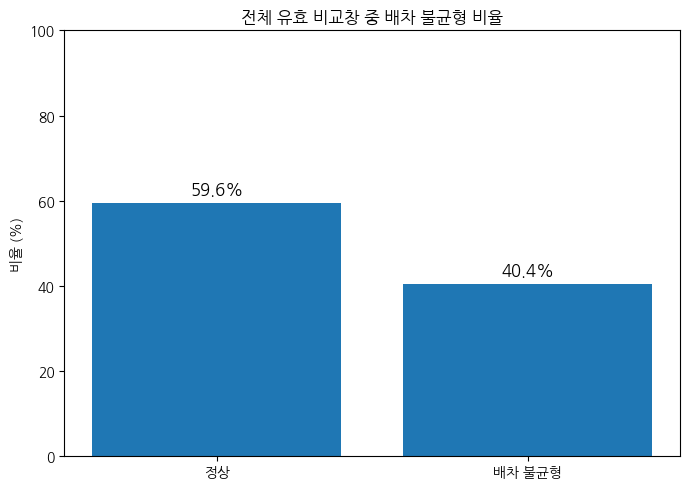

In [27]:
# ============================================================
# 7-1. 전체 유효 비교창 중 배차 불균형 비율 시각화
# ============================================================

import matplotlib.pyplot as plt

total_windows = len(pair21)
imbalance_windows = int(pair21["is_imbalance"].sum())
normal_windows = total_windows - imbalance_windows

imbalance_rate = imbalance_windows / total_windows * 100
normal_rate = normal_windows / total_windows * 100

print(f"전체 유효 비교창: {total_windows}개")
print(f"배차 불균형: {imbalance_windows}개 ({imbalance_rate:.1f}%)")
print(f"정상: {normal_windows}개 ({normal_rate:.1f}%)")

labels = ["정상", "배차 불균형"]
values = [normal_rate, imbalance_rate]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values)

ax.set_ylabel("비율 (%)")
ax.set_ylim(0, 100)
ax.set_title("전체 유효 비교창 중 배차 불균형 비율")

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()


### 7-2. 배차 상태 유형별 비율

전체 유효 비교창을 정상·몰림형·간격편차형으로 구분해 각 유형의 비율을 확인함.


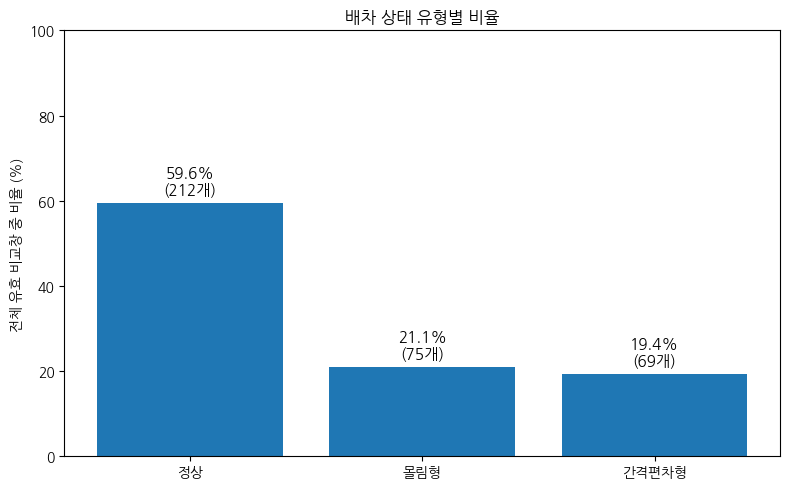

In [28]:
# ============================================================
# 7-2. 정상 / 몰림형 / 간격편차형 비율 시각화
# ============================================================

short_count = int((pair21["imbalance_type"] == "몰림형").sum())
gap_count = int((pair21["imbalance_type"] == "간격편차형").sum())
normal_count = int((~pair21["is_imbalance"]).sum())

type_labels = ["정상", "몰림형", "간격편차형"]
type_counts = [normal_count, short_count, gap_count]
type_rates = [x / len(pair21) * 100 for x in type_counts]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(type_labels, type_rates)

ax.set_ylabel("전체 유효 비교창 중 비율 (%)")
ax.set_ylim(0, 100)
ax.set_title("배차 상태 유형별 비율")

for bar, rate, count in zip(bars, type_rates, type_counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{rate:.1f}%\n({count}개)",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()


### 7-3. 장시간 배차 공백 사례

연속 두 Headway 중 하나라도 30분 이상인 비교창을 추출해 가장 긴 사례를 확인함.이는 불균형 판정 기준이 아닌, 배차 공백이 크게 발생한 사례를 통해 문제의 심각성을 직관적으로 확인하기 위한 것임.

In [29]:
# ============================================================
# 7-3. 실제 관측된 장시간 배차 공백 사례 TOP 5
#     - 연속 두 Headway 중 하나라도 30분 이상인 비교창 추출
#     - 30분은 불균형 판정 기준이 아니라, 문제의 심각성을
#       직관적으로 보여주기 위한 사례 제시 기준임
# ============================================================

long_gap_examples = pair21[
    (pair21["headway_min"] >= 30)
    | (pair21["next_headway_min"] >= 30)
].copy()

# 두 Headway 중 더 긴 값을 대표 공백으로 사용
long_gap_examples["max_headway_min"] = (
    long_gap_examples[["headway_min", "next_headway_min"]]
    .max(axis=1)
)

# 가장 긴 공백부터 정렬
long_gap_examples = (
    long_gap_examples
    .sort_values(
        ["max_headway_min", "date", "arrival_time_est"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

print("30분 이상 Headway가 포함된 비교창 수:", len(long_gap_examples))
print("\n===== 장시간 배차 공백 사례 TOP 5 =====")

display(
    long_gap_examples[
        [
            "date",
            "arrival_time_est",
            "route_pattern",
            "headway_min",
            "next_headway_min",
            "max_headway_min",
            "imbalance_type"
        ]
    ].head(5).round({
        "headway_min": 1,
        "next_headway_min": 1,
        "max_headway_min": 1
    })
)


30분 이상 Headway가 포함된 비교창 수: 155

===== 장시간 배차 공백 사례 TOP 5 =====


,date,arrival_time_est,route_pattern,headway_min,next_headway_min,max_headway_min,imbalance_type
0,2026-09-18,2026-09-18 19:34:48,1330-2 → 1330-4 → 1330-2,14.0,42.0,42.0,간격편차형
1,2026-09-23,2026-09-23 19:34:48,1330-2 → 1330-4 → 1330-4,16.0,40.0,40.0,간격편차형
2,2026-09-23,2026-09-23 20:14:47,1330-4 → 1330-4 → 1330-2,40.0,4.0,40.0,몰림형
3,2026-09-15,2026-09-15 19:32:48,1330-2 → 1330-4 → 1330-4,14.0,38.0,38.0,간격편차형
4,2026-09-15,2026-09-15 20:10:48,1330-4 → 1330-4 → 1330-2,38.0,6.0,38.0,몰림형


## 8. 노선 조합별 분석

연속 3대의 노선 배열별로 전체 비교창 수, 불균형 비교창 수와 발생률을 비교함.


In [30]:
# ============================================================
# 8. 노선 조합별 불균형 발생 분석
# ============================================================

# ------------------------------------------------------------
# 1. 각 노선 조합의 전체 등장 횟수
# ------------------------------------------------------------

total_pattern22 = (
    pair21
    .groupby("route_pattern")
    .size()
    .reset_index(name="total_count")
)


# ------------------------------------------------------------
# 2. 각 노선 조합의 불균형 발생 횟수
# ------------------------------------------------------------

imbalance_pattern22 = (
    imbalance21
    .groupby("route_pattern")
    .size()
    .reset_index(name="imbalance_count")
)


# ------------------------------------------------------------
# 3. 전체 등장 횟수와 불균형 횟수 결합
# ------------------------------------------------------------

pattern_rate22 = (
    total_pattern22
    .merge(
        imbalance_pattern22,
        on="route_pattern",
        how="left"
    )
)

pattern_rate22["imbalance_count"] = (
    pattern_rate22["imbalance_count"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 4. 불균형 발생률
# ------------------------------------------------------------

pattern_rate22["imbalance_rate_pct"] = (
    pattern_rate22["imbalance_count"]
    / pattern_rate22["total_count"]
    * 100
).round(1)


# ------------------------------------------------------------
# 5. 몰림형 / 간격편차형 각각 몇 건인지
# ------------------------------------------------------------

type22 = (
    imbalance21
    .groupby(
        ["route_pattern", "imbalance_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

pattern_rate22 = (
    pattern_rate22
    .merge(
        type22,
        on="route_pattern",
        how="left"
    )
)

for col in ["몰림형", "간격편차형"]:

    if col not in pattern_rate22.columns:
        pattern_rate22[col] = 0

    pattern_rate22[col] = (
        pattern_rate22[col]
        .fillna(0)
        .astype(int)
    )


# ------------------------------------------------------------
# 6. 불균형 발생 횟수 순으로 정렬
# ------------------------------------------------------------

pattern_rate22 = (
    pattern_rate22
    .sort_values(
        ["imbalance_count", "imbalance_rate_pct"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


display(
    pattern_rate22[
        [
            "route_pattern",
            "total_count",
            "imbalance_count",
            "imbalance_rate_pct",
            "몰림형",
            "간격편차형"
        ]
    ]
)

print(
    "전체 비교:",
    pattern_rate22["total_count"].sum()
)

print(
    "전체 불균형:",
    pattern_rate22["imbalance_count"].sum()
)


,route_pattern,total_count,imbalance_count,imbalance_rate_pct,몰림형,간격편차형
0,1330-4 → 1330-44 → 1330-2,52,42,80.8,21,21
1,1330-44 → 1330-2 → 1330-4,61,27,44.3,27,0
2,1330-4 → 1330-4 → 1330-2,25,21,84.0,9,12
3,1330-2 → 1330-4 → 1330-4,60,19,31.7,1,18
4,1330-4 → 1330-2 → 1330-4,44,13,29.5,13,0
5,1330-44 → 1330-4 → 1330-2,19,12,63.2,4,8
6,1330-2 → 1330-4 → 1330-44,36,9,25.0,0,9
7,1330-2 → 1330-4 → 1330-2,1,1,100.0,0,1
8,1330-4 → 1330-4 → 1330-4,1,0,0.0,0,0
9,1330-4 → 1330-4 → 1330-44,36,0,0.0,0,0


전체 비교: 356
전체 불균형: 144


### 8-1. 실제 불균형 사례 상세 확인

불균형으로 판정된 비교창의 날짜·연속 노선·추정 도착시각·두 Headway·불균형 유형을 확인함.


In [31]:
# ============================================================
# 23. 실제 불균형 사례 상세표
#     - 날짜
#     - 연속 노선
#     - 추정 도착시각
#     - 두 Headway
#     - 불균형 유형
# ============================================================

imbalance_detail23 = (
    imbalance21[
        [
            "date",
            "route_pattern",
            "prev_arrival_time",
            "arrival_time_est",
            "next_arrival_time",
            "headway_min",
            "next_headway_min",
            "gap_difference",
            "imbalance_type"
        ]
    ]
    .copy()
    .sort_values(
        ["date", "arrival_time_est"]
    )
    .reset_index(drop=True)
)


# 보기 편하게 시간만 별도 표시
imbalance_detail23["prev_time"] = (
    imbalance_detail23["prev_arrival_time"]
    .dt.strftime("%H:%M:%S")
)

imbalance_detail23["current_time"] = (
    imbalance_detail23["arrival_time_est"]
    .dt.strftime("%H:%M:%S")
)

imbalance_detail23["next_time"] = (
    imbalance_detail23["next_arrival_time"]
    .dt.strftime("%H:%M:%S")
)


# Headway는 보기 편하게 소수점 1자리
imbalance_detail23["headway_min"] = (
    imbalance_detail23["headway_min"].round(1)
)

imbalance_detail23["next_headway_min"] = (
    imbalance_detail23["next_headway_min"].round(1)
)

imbalance_detail23["gap_difference"] = (
    imbalance_detail23["gap_difference"].round(1)
)


display(
    imbalance_detail23[
        [
            "date",
            "route_pattern",
            "prev_time",
            "current_time",
            "next_time",
            "headway_min",
            "next_headway_min",
            "gap_difference",
            "imbalance_type"
        ]
    ]
)

print(
    "전체 불균형 비교 수:",
    len(imbalance_detail23)
)

,date,route_pattern,prev_time,current_time,next_time,headway_min,next_headway_min,gap_difference,imbalance_type
0,2026-09-15,1330-44 → 1330-4 → 1330-2,07:36:47,08:04:48,08:16:47,28.0,12.0,16.0,간격편차형
1,2026-09-15,1330-4 → 1330-44 → 1330-2,08:34:47,09:04:47,09:18:47,30.0,14.0,16.0,간격편차형
2,2026-09-15,1330-4 → 1330-4 → 1330-2,09:36:48,10:06:47,10:18:49,30.0,12.0,18.0,간격편차형
3,2026-09-15,1330-4 → 1330-44 → 1330-2,10:38:47,11:06:49,11:14:48,28.0,8.0,20.0,몰림형
4,2026-09-15,1330-44 → 1330-2 → 1330-4,11:06:49,11:14:48,11:34:47,8.0,20.0,12.0,몰림형
...,...,...,...,...,...,...,...,...,...
139,2026-09-29,1330-4 → 1330-4 → 1330-2,14:36:49,15:06:49,15:20:48,30.0,14.0,16.0,간격편차형
140,2026-09-29,1330-4 → 1330-44 → 1330-2,15:34:47,16:02:47,16:14:51,28.0,12.1,15.9,간격편차형
141,2026-09-29,1330-4 → 1330-44 → 1330-2,17:02:47,17:34:49,17:46:48,32.0,12.0,20.0,간격편차형
142,2026-09-29,1330-4 → 1330-44 → 1330-2,18:34:48,19:06:47,19:18:47,32.0,12.0,20.0,간격편차형


전체 불균형 비교 수: 144


## 9. 시간대별 분석

가운데 차량의 추정 도착시각을 기준으로 2시간 단위 시간대를 구성해 불균형 발생 횟수와 비율을 비교함.


In [32]:
# ============================================================
# 9. 시간대별 배차 불균형 분석
#     - 2시간 단위
#     - 전체 비교 수 / 불균형 수 / 발생률
#     - 몰림형 / 간격편차형
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. 각 비교창의 기준 시간 설정
#    가운데 버스의 추정 도착시각을 기준으로 함
# ------------------------------------------------------------

pair24 = pair21.copy()

pair24["hour"] = (
    pair24["arrival_time_est"].dt.hour
)


# ------------------------------------------------------------
# 2. 2시간 단위 시간대 생성
# ------------------------------------------------------------

bins = [6, 8, 10, 12, 14, 16, 18, 20, 22]

labels = [
    "06~08시",
    "08~10시",
    "10~12시",
    "12~14시",
    "14~16시",
    "16~18시",
    "18~20시",
    "20~22시"
]

pair24["time_band"] = pd.cut(
    pair24["hour"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)


# ------------------------------------------------------------
# 3. 시간대별 전체 비교 수
# ------------------------------------------------------------

total_time24 = (
    pair24
    .groupby(
        "time_band",
        observed=False
    )
    .size()
    .reset_index(name="total_count")
)


# ------------------------------------------------------------
# 4. 시간대별 불균형 수
# ------------------------------------------------------------

imbalance_time24 = (
    pair24[
        pair24["is_imbalance"]
    ]
    .groupby(
        "time_band",
        observed=False
    )
    .size()
    .reset_index(name="imbalance_count")
)


# ------------------------------------------------------------
# 5. 결합 + 불균형 발생률
# ------------------------------------------------------------

time_rate24 = (
    total_time24
    .merge(
        imbalance_time24,
        on="time_band",
        how="left"
    )
)

time_rate24["imbalance_count"] = (
    time_rate24["imbalance_count"]
    .fillna(0)
    .astype(int)
)

time_rate24["imbalance_rate_pct"] = (
    time_rate24["imbalance_count"]
    / time_rate24["total_count"]
    * 100
).round(1)


# ------------------------------------------------------------
# 6. 시간대별 불균형 유형
# ------------------------------------------------------------

type_time24 = (
    pair24[
        pair24["is_imbalance"]
    ]
    .groupby(
        ["time_band", "imbalance_type"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

time_rate24 = (
    time_rate24
    .merge(
        type_time24,
        on="time_band",
        how="left"
    )
)

for col in ["몰림형", "간격편차형"]:

    if col not in time_rate24.columns:
        time_rate24[col] = 0

    time_rate24[col] = (
        time_rate24[col]
        .fillna(0)
        .astype(int)
    )


# ------------------------------------------------------------
# 7. 최종 표
# ------------------------------------------------------------

display(
    time_rate24[
        [
            "time_band",
            "total_count",
            "imbalance_count",
            "imbalance_rate_pct",
            "몰림형",
            "간격편차형"
        ]
    ]
)

print(
    "전체 비교:",
    time_rate24["total_count"].sum()
)

print(
    "전체 불균형:",
    time_rate24["imbalance_count"].sum()
)


,time_band,total_count,imbalance_count,imbalance_rate_pct,몰림형,간격편차형
0,06~08시,36,5,13.9,5,0
1,08~10시,54,24,44.4,10,14
2,10~12시,54,30,55.6,18,12
3,12~14시,45,10,22.2,4,6
4,14~16시,53,24,45.3,8,16
5,16~18시,52,25,48.1,16,9
6,18~20시,46,18,39.1,8,10
7,20~22시,16,8,50.0,6,2


전체 비교: 356
전체 불균형: 144


## 10. 노선 조합 × 시간대 분석

노선 조합과 시간대를 함께 비교해 반복적으로 불균형이 나타나는 조합을 조정 시뮬레이션 대상으로 선정함.


In [33]:
# ============================================================
# 10. 노선 조합 × 시간대별 배차 불균형 분석
#     - 어떤 노선 배열을 어느 시간대에 조정할지 탐색
# ============================================================

import pandas as pd

pair25 = pair24.copy()


# ------------------------------------------------------------
# 1. 노선 조합 × 시간대별 전체 비교 횟수
# ------------------------------------------------------------

total25 = (
    pair25
    .groupby(
        ["time_band", "route_pattern"],
        observed=True
    )
    .size()
    .reset_index(name="total_count")
)


# ------------------------------------------------------------
# 2. 노선 조합 × 시간대별 불균형 횟수
# ------------------------------------------------------------

imbalance25 = (
    pair25[
        pair25["is_imbalance"]
    ]
    .groupby(
        ["time_band", "route_pattern"],
        observed=True
    )
    .size()
    .reset_index(name="imbalance_count")
)


# ------------------------------------------------------------
# 3. 결합
# ------------------------------------------------------------

pattern_time25 = (
    total25
    .merge(
        imbalance25,
        on=["time_band", "route_pattern"],
        how="left"
    )
)

pattern_time25["imbalance_count"] = (
    pattern_time25["imbalance_count"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 4. 불균형 발생률
# ------------------------------------------------------------

pattern_time25["imbalance_rate_pct"] = (
    pattern_time25["imbalance_count"]
    / pattern_time25["total_count"]
    * 100
).round(1)


# ------------------------------------------------------------
# 5. 유형별 건수
# ------------------------------------------------------------

type25 = (
    pair25[
        pair25["is_imbalance"]
    ]
    .groupby(
        ["time_band", "route_pattern", "imbalance_type"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

pattern_time25 = (
    pattern_time25
    .merge(
        type25,
        on=["time_band", "route_pattern"],
        how="left"
    )
)

for col in ["몰림형", "간격편차형"]:
    if col not in pattern_time25.columns:
        pattern_time25[col] = 0

    pattern_time25[col] = (
        pattern_time25[col]
        .fillna(0)
        .astype(int)
    )


# ------------------------------------------------------------
# 6. 표본이 너무 작은 조합 제외
#    해당 시간대에 최소 3회 이상 등장한 조합만 확인
# ------------------------------------------------------------

focus25 = (
    pattern_time25[
        pattern_time25["total_count"] >= 3
    ]
    .copy()
    .sort_values(
        ["imbalance_count", "imbalance_rate_pct"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


display(
    focus25[
        [
            "time_band",
            "route_pattern",
            "total_count",
            "imbalance_count",
            "imbalance_rate_pct",
            "몰림형",
            "간격편차형"
        ]
    ]
)


,time_band,route_pattern,total_count,imbalance_count,imbalance_rate_pct,몰림형,간격편차형
0,16~18시,1330-4 → 1330-44 → 1330-2,16,13,81.2,7,6
1,14~16시,1330-4 → 1330-4 → 1330-2,8,8,100.0,2,6
2,10~12시,1330-4 → 1330-4 → 1330-2,9,8,88.9,4,4
3,10~12시,1330-4 → 1330-44 → 1330-2,9,8,88.9,5,3
4,16~18시,1330-44 → 1330-2 → 1330-4,16,8,50.0,8,0
5,08~10시,1330-4 → 1330-44 → 1330-2,9,7,77.8,3,4
6,08~10시,1330-44 → 1330-4 → 1330-2,9,7,77.8,2,5
7,14~16시,1330-4 → 1330-44 → 1330-2,9,7,77.8,2,5
8,18~20시,1330-4 → 1330-44 → 1330-2,9,7,77.8,4,3
9,18~20시,1330-2 → 1330-4 → 1330-4,16,6,37.5,0,6


## 11. 배차 조정 시뮬레이션

선정된 시간대·노선조합에서 가운데 차량의 시각을 -15분~+15분 범위로 1분씩 조정함. 정상 사례까지 포함해 조정 후 불균형 건수가 가장 적은 값을 탐색함.


In [34]:
# ============================================================
# 11. 핵심 패턴 배차시각 조정 최적화 — 정상 사례 포함
# ============================================================

import pandas as pd
import numpy as np

targets26_1 = [
    ("10~12시", "1330-4 → 1330-44 → 1330-2"),
    ("14~16시", "1330-4 → 1330-4 → 1330-2"),
    ("16~18시", "1330-4 → 1330-44 → 1330-2")
]


def check_imbalance(h1, h2):

    # 비현실적인 간격
    if h1 <= 0 or h2 <= 0:
        return True

    # 몰림형
    short_type = (
        (h1 <= 10)
        or (h2 <= 10)
    )

    # 간격편차형
    gap_type = (
        (h1 > 10)
        and (h2 > 10)
        and (abs(h1 - h2) >= 15)
    )

    return short_type or gap_type


results26_1 = []

for time_band, route_pattern in targets26_1:

    # ★ 정상 + 불균형 모두 포함
    data = pair25[
        (pair25["time_band"].astype(str) == time_band)
        &
        (pair25["route_pattern"] == route_pattern)
    ].copy()

    original_count = data["is_imbalance"].sum()

    for adjustment in range(-15, 16):

        after_status = []
        gap_differences = []

        for _, row in data.iterrows():

            h1_new = row["headway_min"] + adjustment
            h2_new = row["next_headway_min"] - adjustment

            after_status.append(
                check_imbalance(h1_new, h2_new)
            )

            gap_differences.append(
                abs(h1_new - h2_new)
            )

        after_count = sum(after_status)

        results26_1.append({
            "time_band": time_band,
            "route_pattern": route_pattern,

            "total_cases": len(data),

            "before_imbalance_count":
                int(original_count),

            "adjustment_min": adjustment,

            "after_imbalance_count":
                int(after_count),

            "mean_gap_difference_after":
                np.mean(gap_differences)
        })


simulation26_1 = pd.DataFrame(results26_1)

simulation26_1["abs_adjustment"] = (
    simulation26_1["adjustment_min"].abs()
)


# ------------------------------------------------------------
# 최적값 선정
# 1. 전체 사례 중 불균형 최소
# 2. 평균 Headway 차이 최소
# 3. 조정량 최소
# ------------------------------------------------------------

optimal26_1 = (
    simulation26_1
    .sort_values(
        [
            "time_band",
            "route_pattern",
            "after_imbalance_count",
            "mean_gap_difference_after",
            "abs_adjustment"
        ]
    )
    .groupby(
        ["time_band", "route_pattern"],
        as_index=False
    )
    .first()
)


optimal26_1["reduced_cases"] = (
    optimal26_1["before_imbalance_count"]
    - optimal26_1["after_imbalance_count"]
)


def proposal_text(x):

    if x < 0:
        return f"{abs(x):.0f}분 앞당김"

    elif x > 0:
        return f"{x:.0f}분 늦춤"

    return "조정 없음"


optimal26_1["proposal"] = (
    optimal26_1["adjustment_min"]
    .apply(proposal_text)
)


display(
    optimal26_1[
        [
            "time_band",
            "route_pattern",
            "total_cases",
            "before_imbalance_count",
            "proposal",
            "after_imbalance_count",
            "reduced_cases",
            "mean_gap_difference_after"
        ]
    ]
)


,time_band,route_pattern,total_cases,before_imbalance_count,proposal,after_imbalance_count,reduced_cases,mean_gap_difference_after
0,10~12시,1330-4 → 1330-44 → 1330-2,9,8,10분 앞당김,0,8,3.801852
1,14~16시,1330-4 → 1330-4 → 1330-2,8,8,9분 앞당김,0,8,1.739583
2,16~18시,1330-4 → 1330-44 → 1330-2,16,13,10분 앞당김,0,13,4.514583


## 12. 시각화 설정




In [35]:
# ============================================================
# 한글 폰트 설정
# ============================================================

!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


### 12-1. 조정 전·후 불균형 건수

핵심 패턴별 조정 전과 최적 조정 후의 불균형 비교창 수를 비교함.


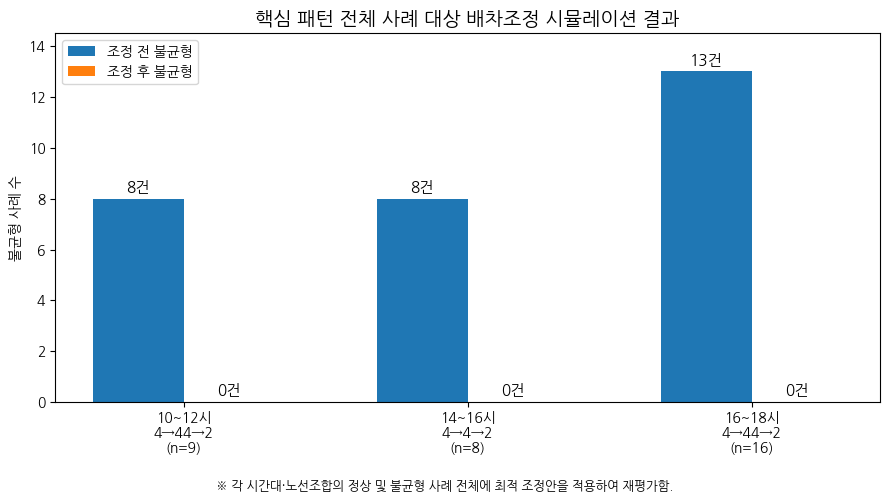

In [36]:
# ============================================================
# 12-1. 핵심 패턴 전체 사례 대상 조정 전·후 불균형 건수
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_opt = optimal26_1.copy()

short_pattern = {
    "1330-4 → 1330-44 → 1330-2": "4→44→2",
    "1330-4 → 1330-4 → 1330-2": "4→4→2"
}

labels = [
    f"{row.time_band}\n{short_pattern.get(row.route_pattern, row.route_pattern)}\n(n={int(row.total_cases)})"
    for row in plot_opt.itertuples()
]

before = plot_opt["before_imbalance_count"].astype(int).tolist()
after = plot_opt["after_imbalance_count"].astype(int).tolist()

x = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, before, width, label="조정 전 불균형")
bars2 = ax.bar(x + width/2, after, width, label="조정 후 불균형")

for bar, value in zip(bars1, before):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.15,
            f"{value}건", ha="center", va="bottom", fontsize=11)

for bar, value in zip(bars2, after):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.15,
            f"{value}건", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("불균형 사례 수")
ax.set_title("핵심 패턴 전체 사례 대상 배차조정 시뮬레이션 결과",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(before + [1]) + 1.5)
ax.legend()

fig.text(
    0.5, 0.01,
    "※ 각 시간대·노선조합의 정상 및 불균형 사례 전체에 최적 조정안을 적용하여 재평가함.",
    ha="center", fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### 12-2. 조정량별 불균형 변화

-15분~+15분의 각 조정값에 따라 불균형 비교창 수가 어떻게 변하는지 확인함.


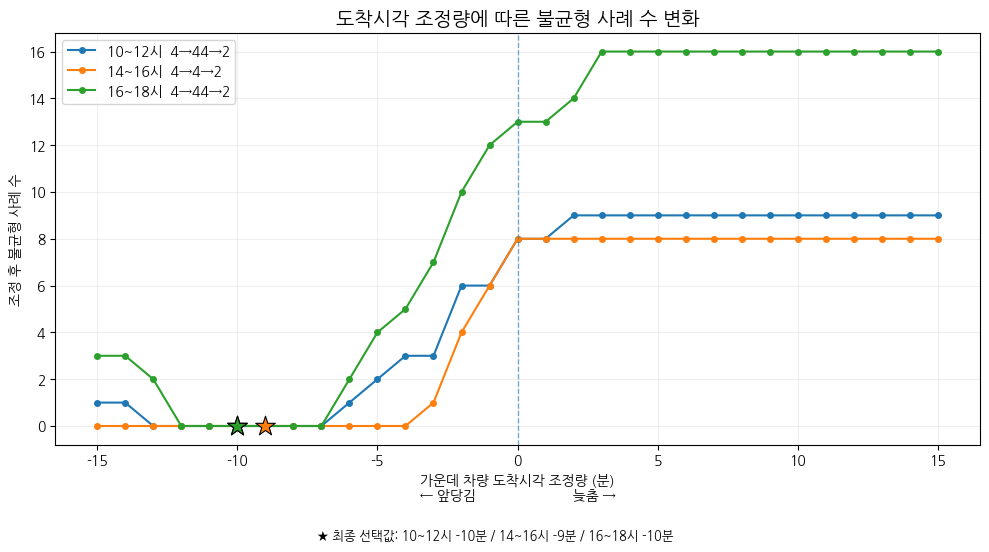

In [37]:
# ============================================================
# 12-2. 조정량에 따른 불균형 사례 수 변화
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

for row in optimal26_1.itertuples():

    temp = simulation26_1[
        (simulation26_1["time_band"] == row.time_band)
        & (simulation26_1["route_pattern"] == row.route_pattern)
    ].sort_values("adjustment_min")

    label = (
        f"{row.time_band}  "
        f"{short_pattern.get(row.route_pattern, row.route_pattern)}"
    )

    line, = ax.plot(
        temp["adjustment_min"],
        temp["after_imbalance_count"],
        marker="o",
        markersize=4,
        label=label
    )

    ax.scatter(
        row.adjustment_min,
        row.after_imbalance_count,
        marker="*",
        s=220,
        color=line.get_color(),
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

ax.axvline(0, linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel(
    "가운데 차량 도착시각 조정량 (분)\n"
    "← 앞당김                         늦춤 →"
)
ax.set_ylabel("조정 후 불균형 사례 수")
ax.set_title("도착시각 조정량에 따른 불균형 사례 수 변화",
             fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.2)

proposal_summary = " / ".join(
    f"{r.time_band} {int(r.adjustment_min):+d}분"
    for r in optimal26_1.itertuples()
)

fig.text(
    0.5, 0.01,
    f"★ 최종 선택값: {proposal_summary}",
    ha="center", fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### 12-3. 조정 전·후 Headway 구조

핵심 패턴의 기존 불균형 사례 중앙값을 대표값으로 사용해 최적 조정 전·후 두 Headway의 변화를 도식화함.


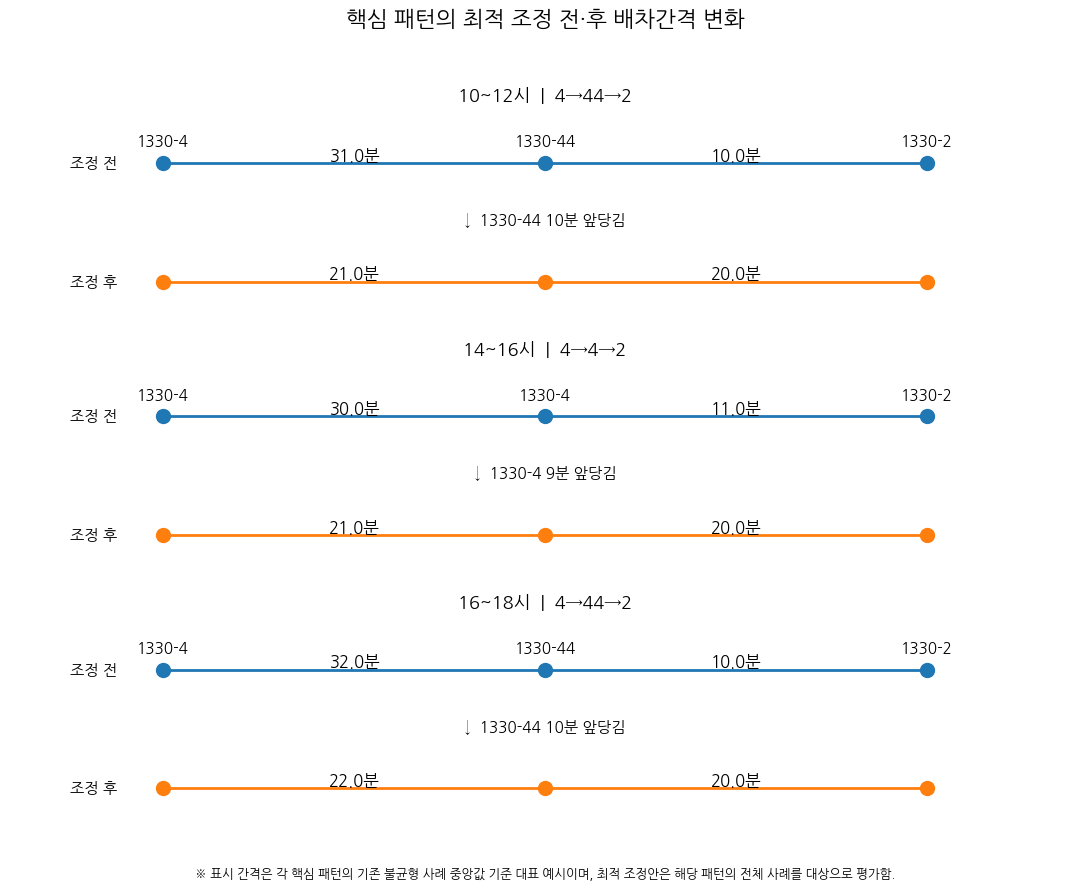

In [38]:
# ============================================================
# 12-3. 최적 조정 전·후 Headway 변화 도식
#      - 각 핵심 패턴의 '기존 불균형 사례 중앙값'을 대표값으로 사용
# ============================================================

cases = []

for row in optimal26_1.itertuples():

    temp = pair25[
        (pair25["time_band"].astype(str) == row.time_band)
        & (pair25["route_pattern"] == row.route_pattern)
        & (pair25["is_imbalance"])
    ].copy()

    h1 = temp["headway_min"].median()
    h2 = temp["next_headway_min"].median()
    adj = row.adjustment_min

    routes = row.route_pattern.split(" → ")

    if adj < 0:
        adjust_text = f"{routes[1]} {abs(int(adj))}분 앞당김"
    elif adj > 0:
        adjust_text = f"{routes[1]} {int(adj)}분 늦춤"
    else:
        adjust_text = "조정 없음"

    cases.append({
        "title": f"{row.time_band}  |  {short_pattern.get(row.route_pattern, row.route_pattern)}",
        "routes": routes,
        "before": [h1, h2],
        "after": [h1 + adj, h2 - adj],
        "adjust": adjust_text
    })

fig, axes = plt.subplots(len(cases), 1, figsize=(11, 3 * len(cases)))

if len(cases) == 1:
    axes = [axes]

for ax, case in zip(axes, cases):
    x = [0, 1, 2]

    ax.plot(x, [1, 1, 1], marker="o", markersize=10, linewidth=2)

    for i, route in enumerate(case["routes"]):
        ax.text(x[i], 1.08, route, ha="center",
                fontsize=11, fontweight="bold")

    ax.text(0.5, 1, f'{case["before"][0]:.1f}분',
            ha="center", va="bottom", fontsize=12)
    ax.text(1.5, 1, f'{case["before"][1]:.1f}분',
            ha="center", va="bottom", fontsize=12)

    ax.text(1, 0.72, f'↓  {case["adjust"]}',
            ha="center", fontsize=11, fontweight="bold")

    ax.plot(x, [0.45, 0.45, 0.45],
            marker="o", markersize=10, linewidth=2)

    ax.text(0.5, 0.45, f'{case["after"][0]:.1f}분',
            ha="center", va="bottom", fontsize=12)
    ax.text(1.5, 0.45, f'{case["after"][1]:.1f}분',
            ha="center", va="bottom", fontsize=12)

    ax.text(-0.12, 1, "조정 전", ha="right", va="center", fontsize=11)
    ax.text(-0.12, 0.45, "조정 후", ha="right", va="center", fontsize=11)

    ax.set_title(case["title"], fontsize=13, fontweight="bold")
    ax.set_xlim(-0.4, 2.4)
    ax.set_ylim(0.25, 1.25)
    ax.axis("off")

fig.suptitle(
    "핵심 패턴의 최적 조정 전·후 배차간격 변화",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.015,
    "※ 표시 간격은 각 핵심 패턴의 기존 불균형 사례 중앙값 기준 대표 예시이며, "
    "최적 조정안은 해당 패턴의 전체 사례를 대상으로 평가함.",
    ha="center", fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
